# Imports

In [3]:
# # use a python 3.11 environment, and install dynamiqs >= 0.3.0

# uncomment and run the line below once to install the required dependencies. You can also install these packages in your terminal using pip.
# !pip install "dynamiqs>=0.3.0" cmaes scipy

In [4]:
import dynamiqs as dq
import jax.numpy as jnp
from matplotlib import pyplot as plt

from jax import vmap, jit
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# dq.set_progress_meter(False)

Estimated cat size: 1.66


|██████████| 100.0% ◆ elapsed 2.25s ◆ remaining 0.00ms  
100%|██████████| 50/50 [00:04<00:00, 10.47it/s]


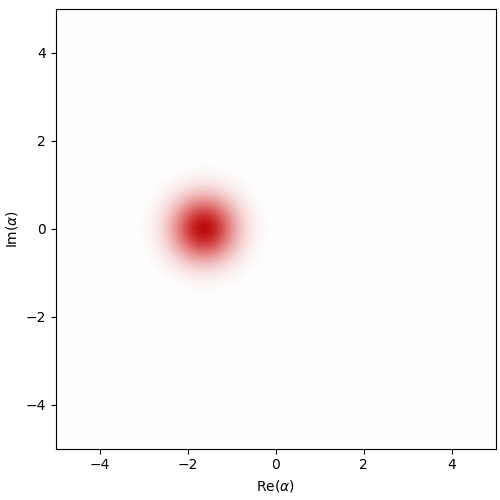

In [5]:
na = 15 # Hilbert space dimension
nb = 5
a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
b = dq.tensor(dq.eye(na), dq.destroy(nb))

kappa_b = 10 # MHz
eps_d = 4
g_2 = 1 # MHz  
kappa_a = 1 # MHz

eps_2 = 2 * g_2 * eps_d / kappa_b
kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

loss_b = jnp.sqrt(kappa_b) * b
loss_a = jnp.sqrt(kappa_a) * a

tsave = jnp.linspace(0, 100, 100)

psi0 = dq.tensor(dq.coherent(na, -alpha_estimate), dq.fock(nb,0)) # initial state

res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave)
dq.plot.wigner_gif(dq.ptrace(res.states, 0))

In [6]:
def measure_lifetime(initial_state, tfinal):
    na = 15 # Hilbert space dimension
    nb = 5
    a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilation operator
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    kappa_b = 10 # MHz
    eps_d = 4
    g_2 = 1 # MHz  
    kappa_a = 1 # MHz

    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
    alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

    print(f"Estimated cat size: {alpha_estimate:.2f}")

    H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

    loss_b = jnp.sqrt(kappa_b) * b
    loss_a = jnp.sqrt(kappa_a) * a

    tsave = jnp.linspace(0, tfinal, 100)

    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / jnp.sqrt(2),
        "-x": (g_state - e_state) / jnp.sqrt(2),
        "+y": (g_state + 1j*e_state) / jnp.sqrt(2),
        "-y": (g_state - 1j*e_state) / jnp.sqrt(2),
    }

    sx = (1j * jnp.pi * a.dag() @ a).expm()
    
    # This construction of sigmaz will not work without a good estimate of alpha, which is hard to come by in experiment.
    sz = basis["+z"] @ basis["+z"].dag() - basis["-z"] @ basis["-z"].dag()
    sz = dq.tensor(sz, dq.eye(nb))

    psi0 = dq.tensor(basis[initial_state], dq.fock(nb,0)) # initial state

    res = dq.mesolve(
        H, 
        [loss_b, loss_a], 
        psi0, 
        tsave, 
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz]
    )

    return res

In [7]:
# model: y = A * exp(-t/tau) + C
def model(p, t):
    A, tau, C = p
    return A * jnp.exp(-t/tau) + C

def residuals(p, x, y):
    return model(p, x) - y


def robust_exp_fit(x, y):
    # smart initialization
    A0 = y.max() - y.min()
    C0 = y.min()
    tau0 = (x.max() - x.min())
    p0 = [A0, tau0, C0]

    # robust fit (soft_l1 or huber are key)
    res = least_squares(
        residuals,
        p0,
        args=(x, y),
        bounds=([0, 0, -jnp.inf], [jnp.inf, jnp.inf, jnp.inf]),
        loss="soft_l1",   # try "huber" too
        f_scale=0.1       # tune based on noise level
    )

    A, tau, C = res.x
    y_fit = model(res.x.copy(), x)

    return {
        "popt": res.x,
        "y_fit": y_fit,
    }

Estimated cat size: 1.66


c:\Users\zoernchen2\miniconda3\envs\myenv\Lib\site-packages\equinox\_module\_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


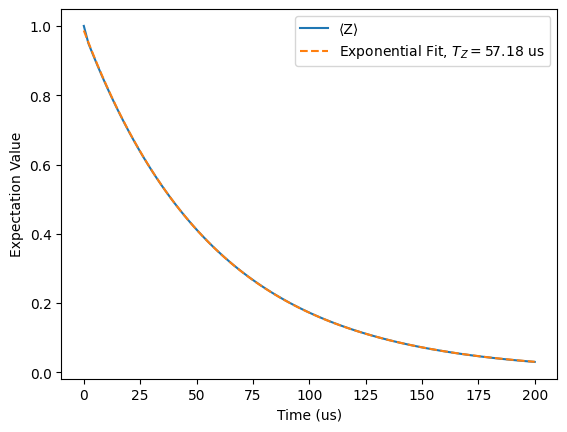

In [8]:
res = measure_lifetime("+z", 200)
szt = res.expects[1,:].real
ts = res.tsave

y = szt 
x = ts 
fit = robust_exp_fit(x, y)
y_fit = fit["y_fit"]
Tz = fit["popt"][1]

plt.plot(ts, szt, label="⟨Z⟩")
plt.plot(ts, y_fit, label="Exponential Fit, $T_Z = $" + "{:.2f}".format(Tz) + " us", linestyle="--")
plt.xlabel("Time (us)")
plt.ylabel("Expectation Value")
plt.legend()
plt.show()